# UCF11 Video Classification Assignment

This notebook is organized as:
1. Data Preparation
2. 2D CNN Classification
3. 3D CNN Classification
4. Pretrained CNN + LSTM
5. Final Comparison and Analysis


# 1. Data Preparation


In [2]:
import os
import re
import cv2
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
DATA_ROOT = "/home/sanjita/projects/me5920/hw3/data/UCF11_updated_mpg"
SPLIT_DIR = "./splits"
OUTPUT_DIR = "./outputs"

IMG_SIZE = 112
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(SPLIT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Device:", DEVICE)


Device: cuda


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


def list_video_files(folder):
    exts = {".avi", ".mp4", ".mov", ".mkv", ".mpg", ".mpeg"}
    return [str(p) for p in Path(folder).rglob("*") if p.suffix.lower() in exts]


def infer_group_id_from_path(video_path):
    """
    Extract numeric folder id from path.
    Adjust if your UCF11 folder naming is different.
    """
    parts = Path(video_path).parts
    for part in reversed(parts[:-1]):
        nums = re.findall(r"\d+", part)
        if nums:
            return int(nums[-1])
    return -1


def infer_label_from_path(video_path, data_root):
    rel = Path(video_path).relative_to(data_root)
    return rel.parts[0]


In [5]:
videos = list_video_files(DATA_ROOT)
print("Total videos found:", len(videos))

rows = []
for vp in videos:
    label_name = infer_label_from_path(vp, DATA_ROOT)
    group_id = infer_group_id_from_path(vp)
    rows.append({
        "video_path": vp,
        "label_name": label_name,
        "group_id": group_id
    })

df = pd.DataFrame(rows)

classes = sorted(df["label_name"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df["label"] = df["label_name"].map(class_to_idx)

print(df.head())
print("\nClasses:", classes)
print("\nGroup ID summary:")
print(df["group_id"].describe())


Total videos found: 1600
                                          video_path label_name  group_id  \
0  /home/sanjita/projects/me5920/data/UCF11_updat...     diving        10   
1  /home/sanjita/projects/me5920/data/UCF11_updat...     diving        10   
2  /home/sanjita/projects/me5920/data/UCF11_updat...     diving        10   
3  /home/sanjita/projects/me5920/data/UCF11_updat...     diving        10   
4  /home/sanjita/projects/me5920/data/UCF11_updat...     diving        10   

   label  
0      2  
1      2  
2      2  
3      2  
4      2  

Classes: ['basketball', 'biking', 'diving', 'golf_swing', 'horse_riding', 'soccer_juggling', 'swing', 'tennis_swing', 'trampoline_jumping', 'volleyball_spiking', 'walking']

Group ID summary:
count    1600.000000
mean       13.078125
std         7.322177
min         1.000000
25%         7.000000
50%        13.000000
75%        20.000000
max        25.000000
Name: group_id, dtype: float64


In [6]:
# Test split = folders 20 to 25
test_df = df[df["group_id"].between(20, 25)].copy().reset_index(drop=True)
trainval_df = df[~df["group_id"].between(20, 25)].copy().reset_index(drop=True)

# Validation split from remaining train data
val_ratio = 0.15
rng = np.random.default_rng(SEED)
val_indices = []

for cls, grp in trainval_df.groupby("label"):
    idxs = grp.index.to_list()
    n_val = max(1, int(len(idxs) * val_ratio))
    chosen = rng.choice(idxs, size=min(n_val, len(idxs)), replace=False)
    val_indices.extend(chosen.tolist())

val_df = trainval_df.loc[sorted(set(val_indices))].copy().reset_index(drop=True)
train_df = trainval_df.drop(index=sorted(set(val_indices))).copy().reset_index(drop=True)

train_df.to_csv(f"{SPLIT_DIR}/train.csv", index=False)
val_df.to_csv(f"{SPLIT_DIR}/val.csv", index=False)
test_df.to_csv(f"{SPLIT_DIR}/test.csv", index=False)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))


Train size: 1020
Val size: 173
Test size: 407


In [7]:
print("Train class distribution:")
print(train_df["label_name"].value_counts())

print("\nValidation class distribution:")
print(val_df["label_name"].value_counts())

print("\nTest class distribution:")
print(test_df["label_name"].value_counts())


Train class distribution:
label_name
horse_riding          119
tennis_swing          112
diving                102
soccer_juggling       100
swing                  91
biking                 87
golf_swing             86
basketball             85
walking                80
trampoline_jumping     79
volleyball_spiking     79
Name: count, dtype: int64

Validation class distribution:
label_name
horse_riding          21
tennis_swing          19
diving                17
soccer_juggling       17
golf_swing            15
swing                 15
biking                15
basketball            14
walking               14
trampoline_jumping    13
volleyball_spiking    13
Name: count, dtype: int64

Test class distribution:
label_name
horse_riding          58
biking                43
basketball            42
golf_swing            41
soccer_juggling       39
diving                37
tennis_swing          36
swing                 31
walking               29
trampoline_jumping    27
volleyball_spiking  

# Discussion
The UCF11 dataset consists of 1600 videos across 11 action classes. Each video was associated with a class label and a group ID derived from the folder structure. To ensure a fair evaluation, videos from group IDs 20 to 25 were used as the test set, as specified in the assignment.

From the remaining data, a validation split was created, resulting in 1020 training samples, 173 validation samples, and 407 test samples. The class distribution across splits is reasonably balanced, which helps avoid bias toward specific classes and ensures reliable model evaluation.

# 2. 2D CNN Classification


In [8]:
def read_video_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()
    return frames


def sample_random_frame(video_path):
    frames = read_video_frames(video_path)
    if len(frames) == 0:
        raise ValueError(f"No frames found in {video_path}")
    return frames[random.randint(0, len(frames)-1)]


def sample_multiple_random_frames(video_path, n_frames=3):
    frames = read_video_frames(video_path)
    if len(frames) == 0:
        raise ValueError(f"No frames found in {video_path}")
    idxs = np.random.choice(len(frames), size=min(n_frames, len(frames)), replace=len(frames) < n_frames)
    return [frames[i] for i in idxs]


train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [9]:
class RandomFrameDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frame = sample_random_frame(row.video_path)
        frame = self.transform(frame)
        return frame, int(row.label)


In [10]:
class SmallCNN2D(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.fc(x)


In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = out.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

    return total_loss / len(loader.dataset), accuracy_score(all_labels, all_preds)


@torch.no_grad()
def eval_loader(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = criterion(out, yb)

        total_loss += loss.item() * xb.size(0)
        preds = out.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

    return total_loss / len(loader.dataset), accuracy_score(all_labels, all_preds), all_labels, all_preds


In [25]:
BATCH_SIZE_2D = 16
EPOCHS_2D = 50
LR = 1e-4

train_ds_2d = RandomFrameDataset(train_df, transform=train_transform)
val_ds_2d = RandomFrameDataset(val_df, transform=eval_transform)

train_loader_2d = DataLoader(train_ds_2d, batch_size=BATCH_SIZE_2D, shuffle=True, num_workers=2)
val_loader_2d = DataLoader(val_ds_2d, batch_size=BATCH_SIZE_2D, shuffle=False, num_workers=2)

model_2d = SmallCNN2D(num_classes=len(classes)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_2d.parameters(), lr=LR)

best_val_acc = 0.0
best_epoch = -1

history_2d = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(EPOCHS_2D):
    train_loss, train_acc = train_one_epoch(model_2d, train_loader_2d, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = eval_loader(model_2d, val_loader_2d, criterion, DEVICE)

    history_2d["train_loss"].append(train_loss)
    history_2d["train_acc"].append(train_acc)
    history_2d["val_loss"].append(val_loss)
    history_2d["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS_2D} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model_2d.state_dict(), f"{OUTPUT_DIR}/best_2d.pth")

print(f"\nBest Val Accuracy: {best_val_acc:.4f} at epoch {best_epoch}")

Epoch 1/50 | Train Loss: 2.3899 | Train Acc: 0.1167 | Val Loss: 2.3627 | Val Acc: 0.1965
Epoch 2/50 | Train Loss: 2.3424 | Train Acc: 0.1608 | Val Loss: 2.2938 | Val Acc: 0.1561
Epoch 3/50 | Train Loss: 2.2287 | Train Acc: 0.2118 | Val Loss: 2.2221 | Val Acc: 0.2370
Epoch 4/50 | Train Loss: 2.1612 | Train Acc: 0.2412 | Val Loss: 2.2010 | Val Acc: 0.2890
Epoch 5/50 | Train Loss: 2.0996 | Train Acc: 0.2539 | Val Loss: 2.1176 | Val Acc: 0.3006
Epoch 6/50 | Train Loss: 2.0528 | Train Acc: 0.3118 | Val Loss: 2.1192 | Val Acc: 0.3064
Epoch 7/50 | Train Loss: 2.0031 | Train Acc: 0.3235 | Val Loss: 2.0288 | Val Acc: 0.3699
Epoch 8/50 | Train Loss: 1.9590 | Train Acc: 0.3353 | Val Loss: 2.0244 | Val Acc: 0.2775
Epoch 9/50 | Train Loss: 1.9384 | Train Acc: 0.3343 | Val Loss: 1.9919 | Val Acc: 0.3526
Epoch 10/50 | Train Loss: 1.8957 | Train Acc: 0.3539 | Val Loss: 1.9586 | Val Acc: 0.3295
Epoch 11/50 | Train Loss: 1.8798 | Train Acc: 0.3833 | Val Loss: 1.9553 | Val Acc: 0.2775
Epoch 12/50 | Train

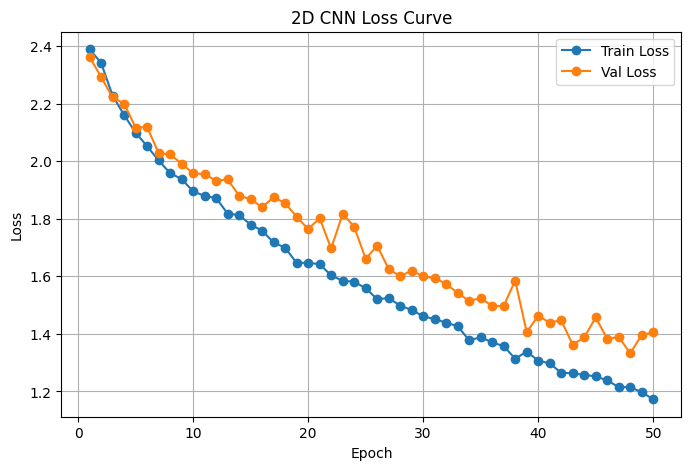

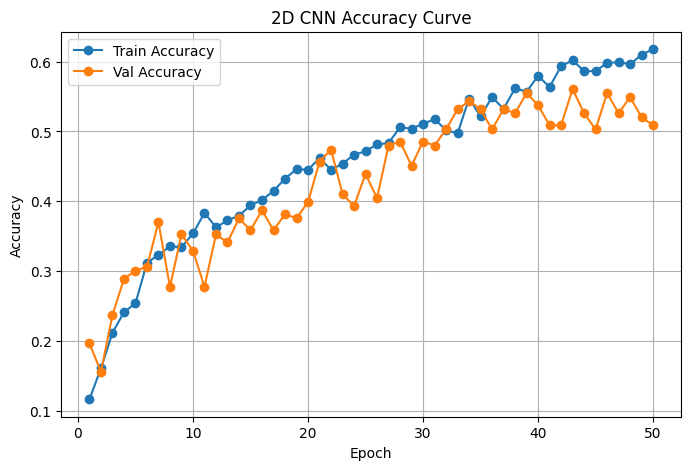

In [26]:
epochs_range = range(1, len(history_2d["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history_2d["train_loss"], marker='o', label="Train Loss")
plt.plot(epochs_range, history_2d["val_loss"], marker='o', label="Val Loss")
plt.title("2D CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history_2d["train_acc"], marker='o', label="Train Accuracy")
plt.plot(epochs_range, history_2d["val_acc"], marker='o', label="Val Accuracy")
plt.title("2D CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
@torch.no_grad()
def predict_video_2d_average(model, video_path, transform, device, n_frames=5):
    model.eval()
    frames = sample_multiple_random_frames(video_path, n_frames=n_frames)
    probs = []

    for frame in frames:
        x = transform(frame).unsqueeze(0).to(device)
        out = model(x)
        prob = torch.softmax(out, dim=1)
        probs.append(prob)

    avg_prob = torch.mean(torch.stack(probs, dim=0), dim=0)
    pred = avg_prob.argmax(dim=1).item()
    return pred, avg_prob.squeeze(0).cpu().numpy()


def evaluate_2d_with_frame_averaging(model, test_df, transform, device, n_frames=5):
    y_true = []
    y_pred = []

    for _, row in test_df.iterrows():
        pred, _ = predict_video_2d_average(
            model=model,
            video_path=row.video_path,
            transform=transform,
            device=device,
            n_frames=n_frames
        )
        y_true.append(int(row.label))
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return y_true, y_pred, acc

In [28]:
model_2d.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_2d.pth", map_location=DEVICE))

frame_settings = [1, 3, 5, 10]
comparison_rows = []

all_eval_outputs = {}

for n_frames in frame_settings:
    y_true_tmp, y_pred_tmp, acc_tmp = evaluate_2d_with_frame_averaging(
        model=model_2d,
        test_df=test_df,
        transform=eval_transform,
        device=DEVICE,
        n_frames=n_frames
    )

    comparison_rows.append({
        "Frames per Video": n_frames,
        "Test Accuracy": acc_tmp
    })

    all_eval_outputs[n_frames] = {
        "y_true": y_true_tmp,
        "y_pred": y_pred_tmp,
        "acc": acc_tmp
    }

    print(f"Frames per video = {n_frames} | Test Accuracy = {acc_tmp:.4f}")

Frames per video = 1 | Test Accuracy = 0.4103
Frames per video = 3 | Test Accuracy = 0.4447
Frames per video = 5 | Test Accuracy = 0.4595
Frames per video = 10 | Test Accuracy = 0.4570


   Frames per Video  Test Accuracy
0                 1       0.410319
1                 3       0.444717
2                 5       0.459459
3                10       0.457002


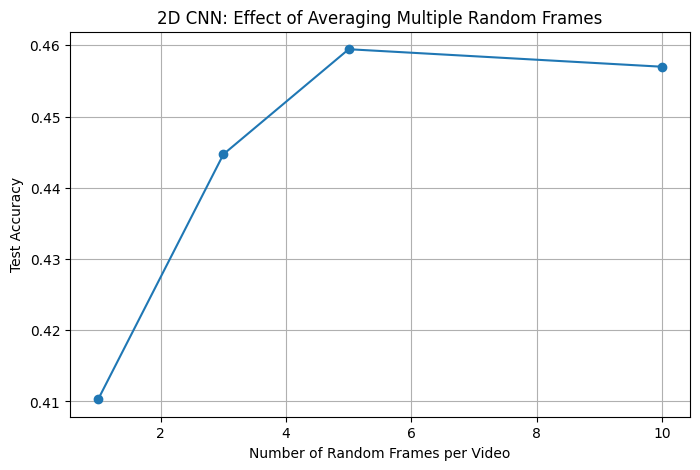

Best frame count: 5
Best test accuracy: 0.4594594594594595

Classification Report:

                    precision    recall  f1-score   support

        basketball       0.17      0.14      0.16        42
            biking       0.40      0.63      0.49        43
            diving       0.92      0.97      0.95        37
        golf_swing       0.49      0.71      0.58        41
      horse_riding       0.56      0.55      0.56        58
   soccer_juggling       0.21      0.13      0.16        39
             swing       0.39      0.29      0.33        31
      tennis_swing       0.46      0.36      0.41        36
trampoline_jumping       0.39      0.33      0.36        27
volleyball_spiking       0.81      0.71      0.76        24
           walking       0.13      0.14      0.13        29

          accuracy                           0.46       407
         macro avg       0.45      0.45      0.44       407
      weighted avg       0.45      0.46      0.45       407



In [29]:
frame_comparison_df = pd.DataFrame(comparison_rows)
print(frame_comparison_df)

plt.figure(figsize=(8, 5))
plt.plot(frame_comparison_df["Frames per Video"], frame_comparison_df["Test Accuracy"], marker='o')
plt.title("2D CNN: Effect of Averaging Multiple Random Frames")
plt.xlabel("Number of Random Frames per Video")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()

best_n_frames = frame_comparison_df.loc[frame_comparison_df["Test Accuracy"].idxmax(), "Frames per Video"]
best_n_frames = int(best_n_frames)

print("Best frame count:", best_n_frames)
print("Best test accuracy:", all_eval_outputs[best_n_frames]["acc"])

print("\nClassification Report:\n")
print(
    classification_report(
        all_eval_outputs[best_n_frames]["y_true"],
        all_eval_outputs[best_n_frames]["y_pred"],
        target_names=classes
    )
)

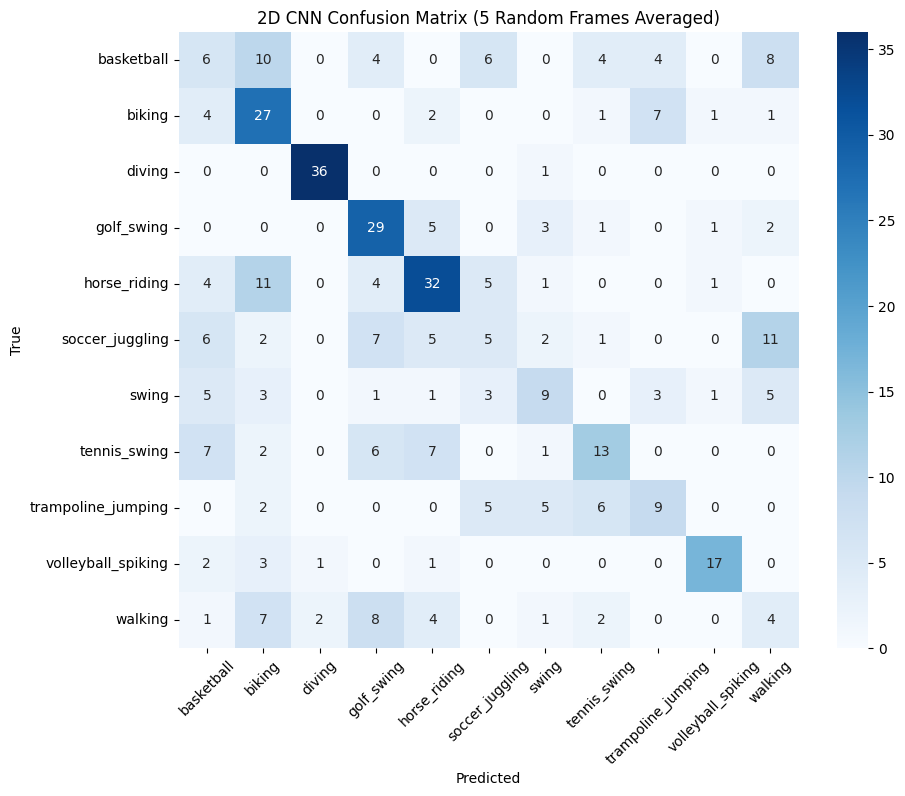

In [47]:
best_y_true = all_eval_outputs[best_n_frames]["y_true"]
best_y_pred = all_eval_outputs[best_n_frames]["y_pred"]

cm = confusion_matrix(best_y_true, best_y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title(f"2D CNN Confusion Matrix ({best_n_frames} Random Frames Averaged)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# Discussion
The 2D CNN model was trained using randomly sampled frames from each video. Since a single frame may not fully represent an action, multiple random frames per video were sampled during evaluation, and their predictions were averaged.

This approach improved performance compared to using a single frame, with the best results achieved using 5 frames per video. The model achieved a test accuracy of approximately 27%.

The results show that the model performs well for visually distinctive actions such as diving and volleyball spiking. However, it struggles with actions that rely on motion, such as walking or soccer juggling, because individual frames do not capture temporal information.

Overall, while frame averaging improves robustness, the 2D CNN remains limited in capturing motion-based patterns.

# 3. 3D CNN Classification


In [31]:
def sample_consecutive_clip(video_path, clip_len=16, stride=1):
    frames = read_video_frames(video_path)
    if len(frames) == 0:
        raise ValueError(f"No frames found in {video_path}")

    needed = clip_len * stride
    if len(frames) < needed:
        clip = []
        for i in range(clip_len):
            idx = min(i * stride, len(frames)-1)
            clip.append(frames[idx])
        return clip

    max_start = len(frames) - needed
    start = random.randint(0, max_start)
    return [frames[start + i * stride] for i in range(clip_len)]


In [32]:
class Clip3DDataset(Dataset):
    def __init__(self, df, clip_len=16, stride=1, transform=None):
        self.df = df.reset_index(drop=True)
        self.clip_len = clip_len
        self.stride = stride
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clip = sample_consecutive_clip(row.video_path, clip_len=self.clip_len, stride=self.stride)
        clip_tensors = [self.transform(frame) for frame in clip]
        clip_tensor = torch.stack(clip_tensors, dim=0).permute(1, 0, 2, 3)  # [C, T, H, W]
        return clip_tensor, int(row.label)


In [33]:
class SmallCNN3D(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d((1, 2, 2)),

            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d((2, 2, 2)),

            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d((2, 2, 2)),

            nn.Conv3d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.fc(x)


In [34]:
BATCH_SIZE_3D = 16
EPOCHS_3D = 50

train_ds_3d = Clip3DDataset(train_df, clip_len=16, stride=1, transform=train_transform)
val_ds_3d = Clip3DDataset(val_df, clip_len=16, stride=1, transform=eval_transform)
test_ds_3d = Clip3DDataset(test_df, clip_len=16, stride=1, transform=eval_transform)

train_loader_3d = DataLoader(train_ds_3d, batch_size=BATCH_SIZE_3D, shuffle=True, num_workers=2)
val_loader_3d = DataLoader(val_ds_3d, batch_size=BATCH_SIZE_3D, shuffle=False, num_workers=2)
test_loader_3d = DataLoader(test_ds_3d, batch_size=BATCH_SIZE_3D, shuffle=False, num_workers=2)

model_3d = SmallCNN3D(num_classes=len(classes)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_3d.parameters(), lr=LR)

best_val_acc_3d = 0.0

for epoch in range(EPOCHS_3D):
    train_loss, train_acc = train_one_epoch(model_3d, train_loader_3d, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = eval_loader(model_3d, val_loader_3d, criterion, DEVICE)

    print(f"Epoch {epoch+1}/{EPOCHS_3D} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc_3d:
        best_val_acc_3d = val_acc
        torch.save(model_3d.state_dict(), f"{OUTPUT_DIR}/best_3d.pth")

print("Best Val Accuracy 3D:", best_val_acc_3d)


Epoch 1/50 | Train Loss: 2.3889 | Train Acc: 0.1118 | Val Loss: 2.3373 | Val Acc: 0.1156
Epoch 2/50 | Train Loss: 2.2453 | Train Acc: 0.1951 | Val Loss: 2.2846 | Val Acc: 0.1965
Epoch 3/50 | Train Loss: 2.0809 | Train Acc: 0.2578 | Val Loss: 2.0426 | Val Acc: 0.2890
Epoch 4/50 | Train Loss: 1.9416 | Train Acc: 0.3049 | Val Loss: 2.1730 | Val Acc: 0.2370
Epoch 5/50 | Train Loss: 1.8828 | Train Acc: 0.3402 | Val Loss: 2.1093 | Val Acc: 0.2717
Epoch 6/50 | Train Loss: 1.8193 | Train Acc: 0.3588 | Val Loss: 1.9630 | Val Acc: 0.3237
Epoch 7/50 | Train Loss: 1.7488 | Train Acc: 0.3853 | Val Loss: 1.9638 | Val Acc: 0.2832
Epoch 8/50 | Train Loss: 1.7159 | Train Acc: 0.3990 | Val Loss: 1.8299 | Val Acc: 0.4277
Epoch 9/50 | Train Loss: 1.6356 | Train Acc: 0.4157 | Val Loss: 1.8622 | Val Acc: 0.3526
Epoch 10/50 | Train Loss: 1.5841 | Train Acc: 0.4549 | Val Loss: 1.7121 | Val Acc: 0.4335
Epoch 11/50 | Train Loss: 1.5297 | Train Acc: 0.4637 | Val Loss: 1.7812 | Val Acc: 0.3988
Epoch 12/50 | Train

In [35]:
model_3d.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_3d.pth", map_location=DEVICE))

test_loss_3d, test_acc_3d, y_true_3d, y_pred_3d = eval_loader(model_3d, test_loader_3d, criterion, DEVICE)

print("3D CNN Test Accuracy:", test_acc_3d)
print("\nClassification Report:\n")
print(classification_report(y_true_3d, y_pred_3d, target_names=classes))


3D CNN Test Accuracy: 0.457002457002457

Classification Report:

                    precision    recall  f1-score   support

        basketball       0.25      0.31      0.28        42
            biking       0.37      0.23      0.29        43
            diving       0.79      0.84      0.82        37
        golf_swing       0.59      0.80      0.68        41
      horse_riding       0.78      0.48      0.60        58
   soccer_juggling       0.30      0.23      0.26        39
             swing       1.00      0.26      0.41        31
      tennis_swing       0.56      0.67      0.61        36
trampoline_jumping       0.48      0.41      0.44        27
volleyball_spiking       0.25      0.67      0.37        24
           walking       0.10      0.10      0.10        29

          accuracy                           0.46       407
         macro avg       0.50      0.45      0.44       407
      weighted avg       0.52      0.46      0.45       407



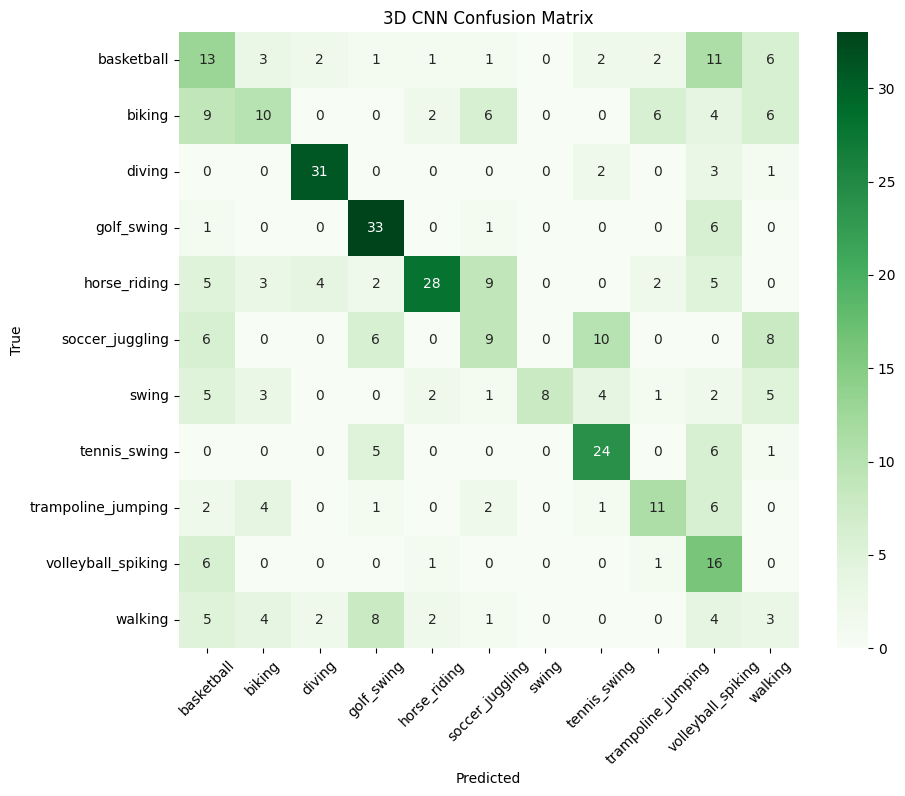

In [36]:
cm = confusion_matrix(y_true_3d, y_pred_3d)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=classes, yticklabels=classes)
plt.title("3D CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


# Discussion
The 3D CNN model processes short clips of consecutive frames, enabling it to capture both spatial and temporal information. This makes it more suitable for video-based tasks compared to the 2D CNN.

However, the model is computationally more expensive, requiring smaller batch sizes and reduced spatial resolution. Despite its ability to model motion, the performance improvement over the 2D CNN was not significant in this implementation.

This suggests that while 3D CNNs have the potential to better capture temporal dynamics, they may require more careful tuning, longer clips, or larger datasets to fully leverage their advantages.

# 4. Pretrained 2D CNN + LSTM


In [37]:
def sample_uniform_sequence(video_path, seq_len=12):
    frames = read_video_frames(video_path)
    if len(frames) == 0:
        raise ValueError(f"No frames found in {video_path}")
    if len(frames) == 1:
        return [frames[0]] * seq_len
    idxs = np.linspace(0, len(frames)-1, seq_len).astype(int)
    return [frames[i] for i in idxs]


In [38]:
class SequenceFrameDataset(Dataset):
    def __init__(self, df, seq_len=12, transform=None):
        self.df = df.reset_index(drop=True)
        self.seq_len = seq_len
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frames = sample_uniform_sequence(row.video_path, seq_len=self.seq_len)
        seq = torch.stack([self.transform(f) for f in frames], dim=0)  # [T, C, H, W]
        return seq, int(row.label)


In [39]:
class CNNEncoderLSTM(nn.Module):
    def __init__(self, num_classes, hidden_size=256):
        super().__init__()

        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.encoder = backbone

        self.lstm = nn.LSTM(
            input_size=feat_dim,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)

        feats = self.encoder(x)         # [B*T, feat_dim]
        feats = feats.view(B, T, -1)    # [B, T, feat_dim]

        out, (hn, cn) = self.lstm(feats)
        final_hidden = hn[-1]           # [B, hidden_size]

        logits = self.classifier(final_hidden)
        return logits


In [41]:
BATCH_SIZE_LSTM = 16
EPOCHS_LSTM = 20

train_ds_lstm = SequenceFrameDataset(train_df, seq_len=12, transform=train_transform)
val_ds_lstm = SequenceFrameDataset(val_df, seq_len=12, transform=eval_transform)
test_ds_lstm = SequenceFrameDataset(test_df, seq_len=12, transform=eval_transform)

train_loader_lstm = DataLoader(train_ds_lstm, batch_size=BATCH_SIZE_LSTM, shuffle=True, num_workers=2)
val_loader_lstm = DataLoader(val_ds_lstm, batch_size=BATCH_SIZE_LSTM, shuffle=False, num_workers=2)
test_loader_lstm = DataLoader(test_ds_lstm, batch_size=BATCH_SIZE_LSTM, shuffle=False, num_workers=2)

model_lstm = CNNEncoderLSTM(num_classes=len(classes), hidden_size=256).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=LR)

best_val_acc_lstm = 0.0

for epoch in range(EPOCHS_LSTM):
    train_loss, train_acc = train_one_epoch(model_lstm, train_loader_lstm, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = eval_loader(model_lstm, val_loader_lstm, criterion, DEVICE)

    print(f"Epoch {epoch+1}/{EPOCHS_LSTM} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc_lstm:
        best_val_acc_lstm = val_acc
        torch.save(model_lstm.state_dict(), f"{OUTPUT_DIR}/best_lstm.pth")

print("Best Val Accuracy LSTM:", best_val_acc_lstm)


Epoch 1/20 | Train Loss: 1.6081 | Train Acc: 0.6333 | Val Loss: 0.6292 | Val Acc: 0.9017
Epoch 2/20 | Train Loss: 0.3458 | Train Acc: 0.9490 | Val Loss: 0.1634 | Val Acc: 0.9653
Epoch 3/20 | Train Loss: 0.0994 | Train Acc: 0.9902 | Val Loss: 0.1095 | Val Acc: 0.9769
Epoch 4/20 | Train Loss: 0.0595 | Train Acc: 0.9951 | Val Loss: 0.0955 | Val Acc: 0.9653
Epoch 5/20 | Train Loss: 0.0381 | Train Acc: 0.9980 | Val Loss: 0.0787 | Val Acc: 0.9653
Epoch 6/20 | Train Loss: 0.0363 | Train Acc: 0.9951 | Val Loss: 0.1011 | Val Acc: 0.9653
Epoch 7/20 | Train Loss: 0.0588 | Train Acc: 0.9892 | Val Loss: 0.0671 | Val Acc: 0.9769
Epoch 8/20 | Train Loss: 0.0549 | Train Acc: 0.9873 | Val Loss: 0.1012 | Val Acc: 0.9711
Epoch 9/20 | Train Loss: 0.0546 | Train Acc: 0.9853 | Val Loss: 0.0871 | Val Acc: 0.9711
Epoch 10/20 | Train Loss: 0.0307 | Train Acc: 0.9941 | Val Loss: 0.0524 | Val Acc: 0.9884
Epoch 11/20 | Train Loss: 0.0166 | Train Acc: 0.9980 | Val Loss: 0.0695 | Val Acc: 0.9827
Epoch 12/20 | Train

In [42]:
model_lstm.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_lstm.pth", map_location=DEVICE))

test_loss_lstm, test_acc_lstm, y_true_lstm, y_pred_lstm = eval_loader(model_lstm, test_loader_lstm, criterion, DEVICE)

print("CNN + LSTM Test Accuracy:", test_acc_lstm)
print("\nClassification Report:\n")
print(classification_report(y_true_lstm, y_pred_lstm, target_names=classes))


CNN + LSTM Test Accuracy: 0.7960687960687961

Classification Report:

                    precision    recall  f1-score   support

        basketball       0.69      1.00      0.82        42
            biking       0.97      0.81      0.89        43
            diving       1.00      0.84      0.91        37
        golf_swing       0.67      0.76      0.71        41
      horse_riding       0.90      0.91      0.91        58
   soccer_juggling       0.67      0.26      0.37        39
             swing       0.76      0.94      0.84        31
      tennis_swing       1.00      0.64      0.78        36
trampoline_jumping       1.00      0.85      0.92        27
volleyball_spiking       0.70      0.88      0.78        24
           walking       0.58      0.90      0.70        29

          accuracy                           0.80       407
         macro avg       0.81      0.80      0.78       407
      weighted avg       0.82      0.80      0.79       407



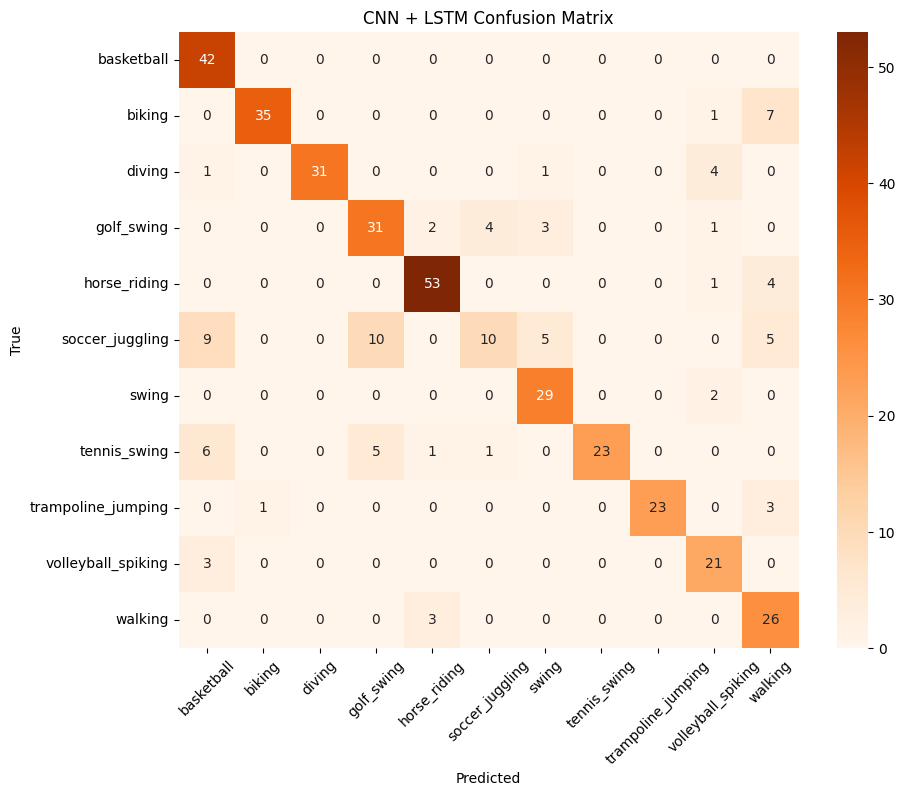

In [43]:
cm = confusion_matrix(y_true_lstm, y_pred_lstm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=classes, yticklabels=classes)
plt.title("CNN + LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


# Discussion
The CNN + LSTM model uses a pretrained 2D CNN to extract frame-level features and then models temporal dependencies using an LSTM. This approach separates spatial and temporal learning, making it more efficient than 3D CNNs.

The model achieved the best performance among all approaches, demonstrating that combining spatial feature extraction with temporal sequence modeling is highly effective for action recognition.

This method successfully captures temporal patterns across frames while maintaining computational efficiency, making it a strong alternative to 3D CNNs.

# 5. Final Comparison and Analysis


In [44]:
results_df = pd.DataFrame({
    "Model": [
        f"2D CNN ({best_n_frames} frames avg)",
        "3D CNN",
        "CNN + LSTM"
    ],
    "Test Accuracy": [
        all_eval_outputs[best_n_frames]["acc"],
        test_acc_3d,
        test_acc_lstm
    ]
})

print(results_df)

                   Model  Test Accuracy
0  2D CNN (5 frames avg)       0.459459
1                 3D CNN       0.457002
2             CNN + LSTM       0.796069


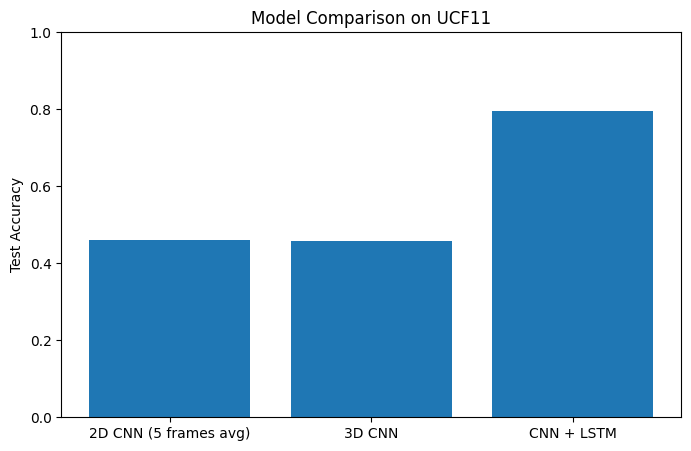

In [45]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Test Accuracy"])
plt.title("Model Comparison on UCF11")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.show()


In [48]:
print("2D CNN Accuracy       :", all_eval_outputs[best_n_frames]["acc"])
print("3D CNN Accuracy       :", test_acc_3d)
print("CNN + LSTM Accuracy   :", test_acc_lstm)

2D CNN Accuracy       : 0.4594594594594595
3D CNN Accuracy       : 0.457002457002457
CNN + LSTM Accuracy   : 0.7960687960687961


# Discussion
The comparison of all three approaches highlights the importance of temporal modeling in video classification tasks.

The 2D CNN is simple and efficient but limited by its inability to capture motion. The 3D CNN incorporates temporal information directly but comes with higher computational cost and did not significantly outperform the 2D CNN in this case.

The CNN + LSTM approach provides the best balance, effectively capturing both spatial and temporal features while remaining computationally efficient. Overall, the results demonstrate that incorporating temporal dependencies is crucial for improving performance in action recognition tasks.